# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [9]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [11]:
df.info(), df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[us]
 1   region        160 non-null    str           
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 8.3 KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [12]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.


region:
region
West     47
East     42
South    36
North    35
Name: count, dtype: int64
region
West     0.294
East     0.262
South    0.225
North    0.219
Name: proportion, dtype: float64


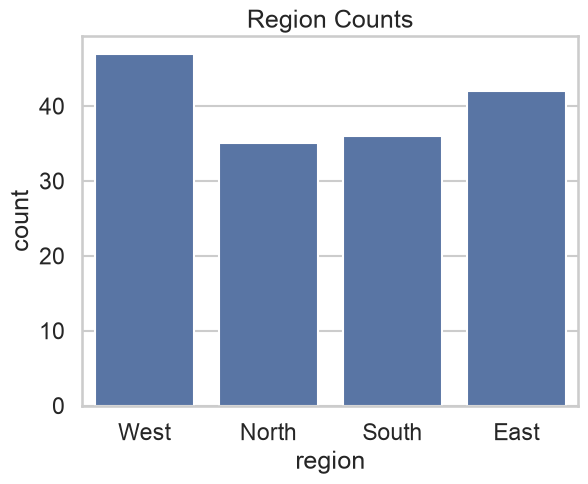

In [19]:
cat_cols = df.select_dtypes(exclude=['number', 'datetime64[ns]']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3))

sns.countplot(data=df, x='region')
plt.title('Region Counts')
plt.show()

## 3) Distributions — two worked examples below; add at least one more

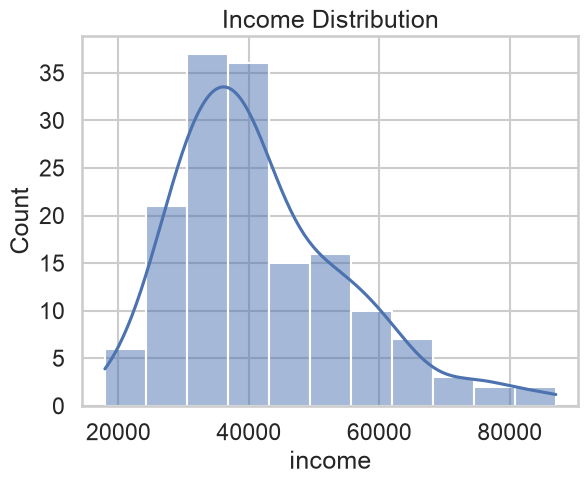

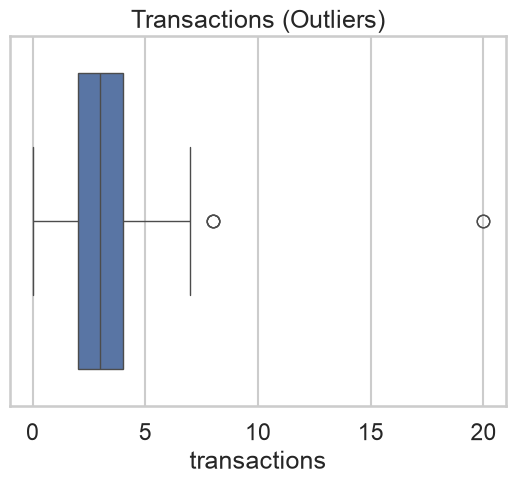

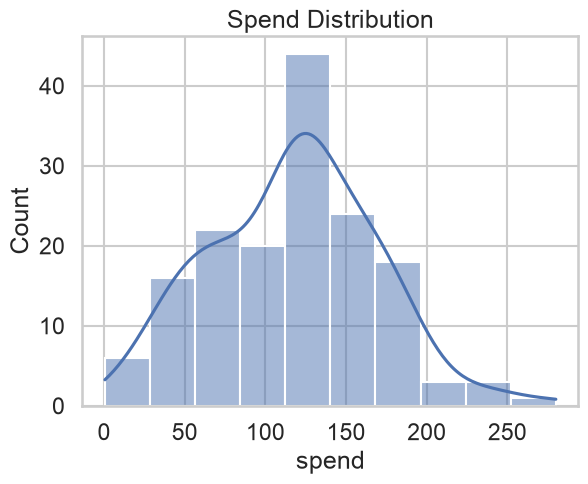

In [14]:
# Example 1 of 2 — histogram + KDE. Keep it, or swap in a column of your own.
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.show()

# Example 2 of 2 — boxplot, to expose outliers.
#
# TODO: add ONE more distribution below, on a column of your choosing (3 are required).
sns.boxplot(x=df['transactions'])
plt.title('Transactions (Outliers)')
plt.show()

sns.histplot(df['spend'], kde=True)
plt.title('Spend Distribution')
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

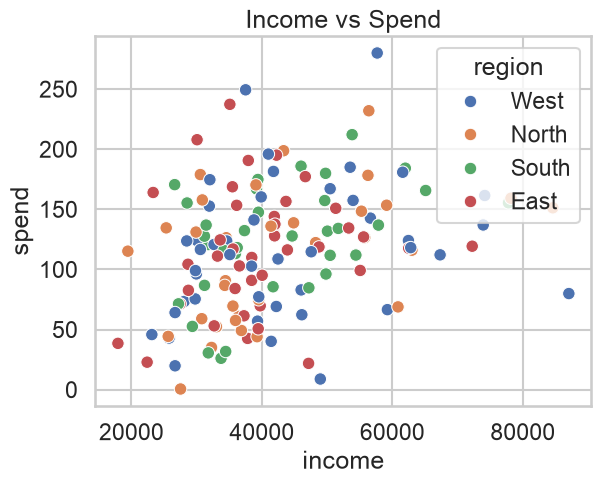

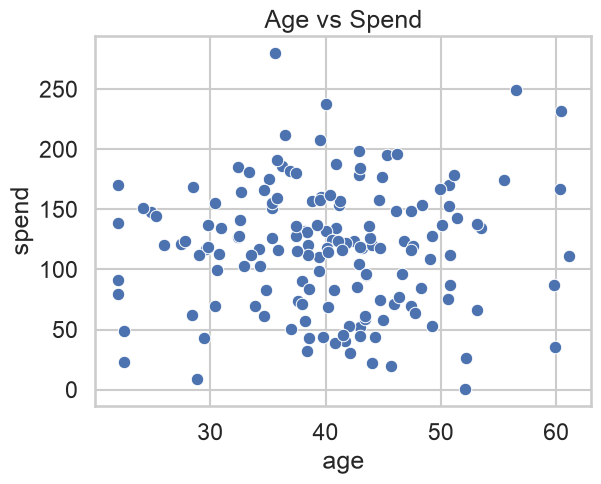

In [15]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

Missing dates: 0


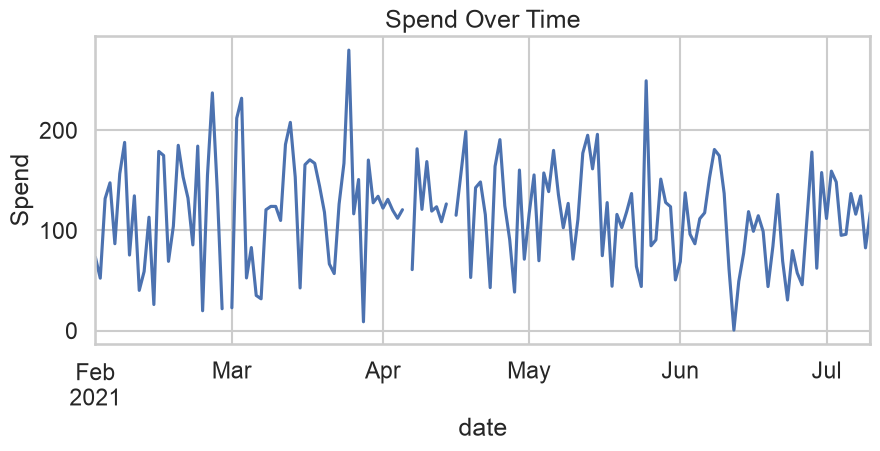

In [16]:
df_time = df.sort_values('date').set_index('date')

full_range = pd.date_range(df_time.index.min(), df_time.index.max(), freq='D')
missing_dates = full_range.difference(df_time.index)
print(f"Missing dates: {len(missing_dates)}")

df_time['spend'].plot(figsize=(10, 4))
plt.title('Spend Over Time')
plt.ylabel('Spend')
plt.show()

Spend doesn't really go up or down over time, just bounces around randomly since the
data is fake. No missing dates either, which is good for later when we do rolling
averages.

## 5) (Optional) Correlation matrix

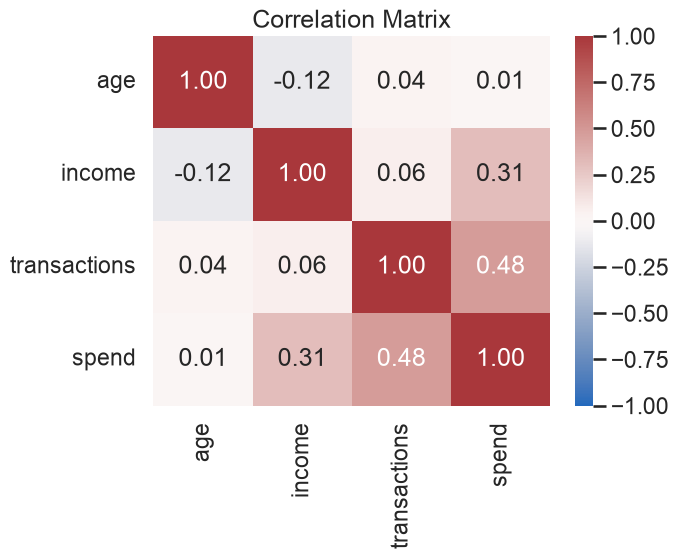

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [17]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [18]:
import sys
sys.path.append('.')
from src.eda import eda_summary

eda_summary(df)

,dtype,missing_pct,n_unique,mean,std
date,datetime64[us],0.00,160,NaN,NaN
region,str,0.00,4,NaN,NaN
age,float64,0.00,122,40.018750,8.458676
income,float64,3.12,155,41983.866323,13262.457038
transactions,int64,0.00,10,3.237500,2.585610
spend,float64,1.88,156,117.291592,51.768645


## 6) Insights & Assumptions

**Top 3 insights:**
- Income and spend are mildly related but not tightly , the scatter shows a loose upward trend, not a clean line.
- Transactions has a couple of clear outliers , visible in the boxplot.
- No trend or seasonality over time , spend just fluctuates around a level.

**Assumptions & risks:**
- The data is synthetic, so relationships here won't match real customer behavior.
- Assuming missing income/spend values are random 
**Next steps before modeling:**
- Handle the income/spend missing values .
- Consider capping or flagging the transaction outliers before feature engineering